# Graph Analyze : clustering

```networkx``` documentation available [here](https://networkx.org/documentation/stable/reference/algorithms/index.html)

## 0 - Data Reading

In [1]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

subset = "sup70tweet"
df = pd.read_csv(f'data\\{subset}.csv')
df.drop(columns=["location"], inplace=True)
df.head()

,reference,date,username,tweet
0,1467835305,Mon Apr 06 22:26:10 PDT 2009,MissLaura317,"@januarycrimson Sorry, babe!! My fam annoys m..."
1,1467836448,Mon Apr 06 22:26:27 PDT 2009,Dogbook,Strider is a sick little puppy http://apps.fa...
2,1467837762,Mon Apr 06 22:26:48 PDT 2009,Dogbook,Emily will be glad when Mommy is done training...
3,1467855981,Mon Apr 06 22:31:37 PDT 2009,Hollywood_Trey,@naughtyhaughty I had on my page for sooooo lo...
4,1467916959,Mon Apr 06 22:48:04 PDT 2009,_emmajane_,@OfficialRandL when is the announcement? i sta...


## 1 - Graph Definition
use of the ```networkx``` to generate a graph from the matrix of similarities

In [2]:
# Symmetric biased random matrix generator
def gen_matrix(N, max_val=10, lam=2.0, seed=42):
    """Generate an N x N symmetric integer matrix in [0, max_val] biased toward 0.

    Distribution: Poisson(lam) clipped to [0, max_val].
    Symmetry: Upper triangle sampled then mirrored.

    Args:
        N (int): Matrix dimension.
        max_val (int): Maximum (inclusive) value allowed.
        seed (int): RNG seed for reproducibility.
        lam (float): Lambda parameter for Poisson (smaller => more zeros).
    Returns:
        np.ndarray: Symmetric (N,N) integer matrix.
    """
    if N <= 0:
        raise ValueError("N must be positive.")
    rng = np.random.default_rng(seed)
    vals = rng.poisson(lam=lam, size=(N, N))
    vals = np.clip(vals, 0, max_val).astype(int)
    upper = np.triu(vals)
    mat = upper + upper.T - np.diag(np.diag(upper))
    return mat

# Demo / quick check
M = gen_matrix(10, max_val=5, lam=1.5, seed=5)
print(M)
print("Symmetric:", np.all(M == M.T))

# Optional: threshold tiny weights to zero
threshold = 0
M_thr = M.copy()
np.fill_diagonal(M_thr, 0)
M_thr[M_thr <= threshold] = 0

# Use sparse to drop zero entries automatically
A = sparse.csr_array(M_thr)
G = nx.from_scipy_sparse_array(A, create_using=nx.Graph)

Gd = nx.from_numpy_array(M, create_using=nx.DiGraph)
Gd.remove_edges_from(nx.selfloop_edges(Gd))
Gd.remove_edges_from([(u, v) for u, v, d in Gd.edges(data=True) if d.get("weight", 0) <= 0])


[[3 0 1 0 0 2 4 2 1 1]
 [0 2 1 1 0 2 0 3 2 1]
 [1 1 3 2 3 0 1 2 1 2]
 [0 1 2 1 4 1 1 1 2 1]
 [0 0 3 4 0 3 3 2 3 0]
 [2 2 0 1 3 0 2 1 3 2]
 [4 0 1 1 3 2 0 2 2 2]
 [2 3 2 1 2 1 2 1 0 0]
 [1 2 1 2 3 3 2 0 0 0]
 [1 1 2 1 0 2 2 0 0 1]]
Symmetric: True


## 2 - Graph Visualization

Colorbar: it shows how edge weights map to colors. We compute the minimum and maximum edge weights in the plotted graph, then linearly normalize each weight to [0, 1]. That normalized value is passed into the chosen colormap (default: viridis). Hence:
- lowest-weight edges take the colormap’s start color; highest-weight edges take the end color
- intermediate weights interpolate in between
Additionally, edge thickness scales with the same normalized weight (1 + 3 × normalized_weight), so strong connections stand out both in color and in width. If there are no edges, the colorbar is omitted.

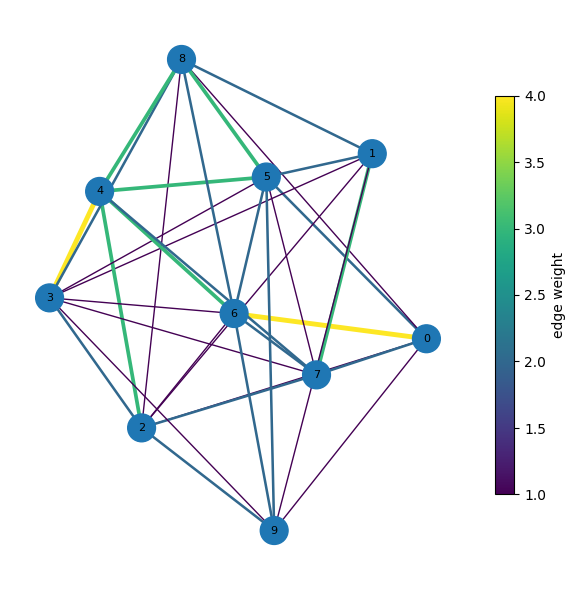

In [3]:
# Simple visualization of the best partition
def visualize_graph(G, labels=None, title=None):
    """Show nodes colored by cluster labels and edges colored by their weight with a colorbar.

    - Nodes: colored by cluster (categorical colormap), with text labels.
    - Edges: colored by weight (continuous colormap), with colorbar.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize

    pos = nx.spring_layout(G, seed=42)
    # Node colors by cluster labels (categorical colormap)
    node_cmap = plt.get_cmap('tab20')
    # Edge colors by weight (continuous colormap)
    edge_cmap = plt.get_cmap('viridis')

    # Gather edge weights
    weights = [d.get('weight', 1) for *_, d in G.edges(data=True)]
    w_min, w_max = (min(weights), max(weights)) if len(weights) else (0, 1)
    norm = Normalize(vmin=w_min, vmax=w_max if w_max > w_min else w_min + 1)
    edge_widths = [1.0 + 2.5 * norm(w) for w in weights] if len(weights) else 1.0

    fig, ax = plt.subplots(figsize=(6, 6))
    # Draw nodes with cluster colors
    if labels is None:
        labels = [0] * G.number_of_nodes()
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=labels, cmap=node_cmap, node_size=400)
    # Draw edges colored by weight
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=weights, edge_cmap=edge_cmap, edge_vmin=w_min, edge_vmax=w_max, width=edge_widths)
    # Node labels (names)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

    # Colorbar for edges only
    sm = plt.cm.ScalarMappable(norm=norm, cmap=edge_cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.7, label='edge weight')

    if title:
        ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

visualize_graph(G)

## 3 - Clustering
### Method 1 - Louvain

Best resolution: 1.0, modularity=0.0894, communities=3
Robustness (ARI mean ± std at best resolution): 1.000 ± 0.000

Resolution  | Modularity(mean±std) | Avg #Communities
0.5        | 0.0000 ± 0.0000    | 1.00
0.8        | 0.0000 ± 0.0000    | 1.00
1.0        | 0.0894 ± 0.0000    | 3.00
1.2        | 0.0649 ± 0.0004    | 4.00
1.5        | 0.0351 ± 0.0000    | 5.00


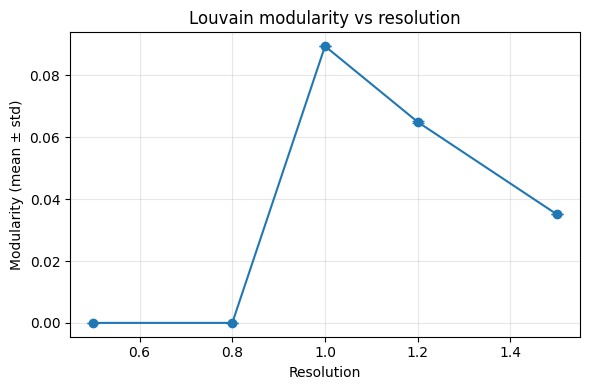

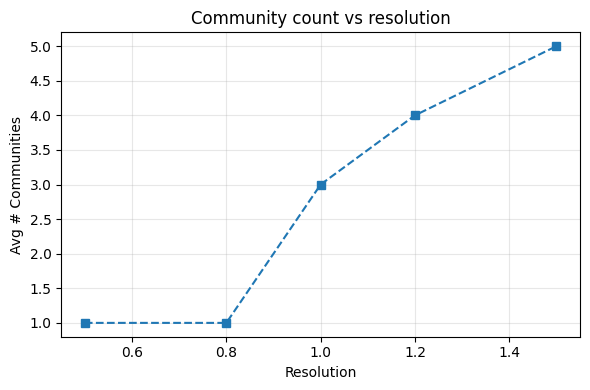

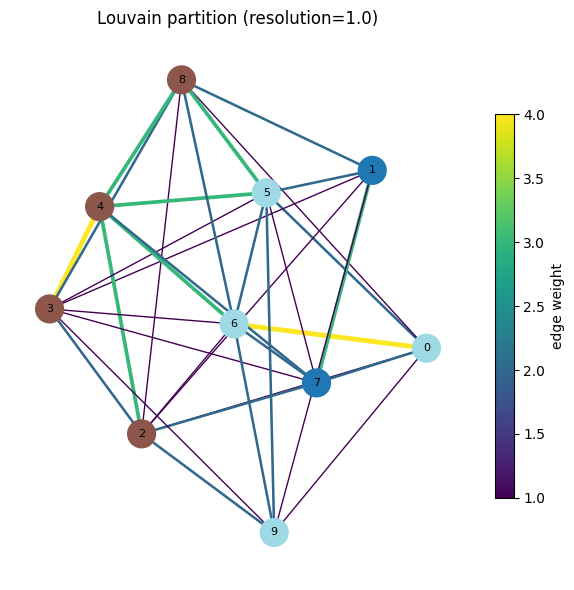

In [5]:
plot_perf = 1

def communities_to_labels(communities, n_nodes):
    """Convert list of sets of nodes to a label array indexed by node id (assumes 0..n-1)."""
    labels = np.empty(n_nodes, dtype=int)
    for cid, comm in enumerate(communities):
        for node in comm:
            labels[node] = cid
    return labels

def run_louvain_resolution_scan(G, resolutions=(0.5, 0.8, 1.0, 1.2, 1.5), seeds=(0, 1, 2), weight='weight'):
    """Run Louvain for multiple resolutions and seeds; collect modularity statistics.

    Returns: list of dicts with keys: resolution, seed, modularity, n_comm, communities.
    """
    results = []
    for r in resolutions:
        for s in seeds:
            comms = louvain_communities(G, weight=weight, resolution=r, seed=s)
            mod = modularity(G, comms, weight=weight)
            results.append({'resolution': r, 'seed': s, 'modularity': mod, 'n_comm': len(comms), 'communities': comms})
    return results

def summarize_results(results):
    # Aggregate modularity per resolution
    summary = {}
    for r in sorted({d['resolution'] for d in results}):
        mods = [d['modularity'] for d in results if d['resolution'] == r]
        n_comms = [d['n_comm'] for d in results if d['resolution'] == r]
        summary[r] = {'mod_mean': np.mean(mods), 'mod_std': np.std(mods), 'n_comm_mean': np.mean(n_comms)}
    return summary

def choose_best_partition(results):
    # Pick partition with highest modularity; tie-breaker: fewer communities
    best = None
    for d in results:
        if best is None or d['modularity'] > best['modularity'] or (d['modularity'] == best['modularity'] and d['n_comm'] < best['n_comm']):
            best = d
    return best

def robustness_ari(results, resolution):
    # Compute ARI between all seed pairs at given resolution
    parts = [d for d in results if d['resolution'] == resolution]
    label_arrays = [communities_to_labels(p['communities'], G.number_of_nodes()) for p in parts]
    aris = []
    for (i, lab1), (j, lab2) in combinations(enumerate(label_arrays), 2):
        aris.append(adjusted_rand_score(lab1, lab2))
    return aris

# Ensure we use undirected graph for Louvain (directed version may be converted)
if Gd.is_directed():
    G_undirected_from_directed = Gd.to_undirected()
else:
    G_undirected_from_directed = Gd

resolutions = (0.5, 0.8, 1.0, 1.2, 1.5)
seeds = range(5)
results = run_louvain_resolution_scan(G, resolutions=resolutions, seeds=seeds)
summary = summarize_results(results)
best = choose_best_partition(results)
best_labels = communities_to_labels(best['communities'], G.number_of_nodes())
best_aris = robustness_ari(results, best['resolution'])

print(f"Best resolution: {best['resolution']}, modularity={best['modularity']:.4f}, communities={best['n_comm']}")
print(f"Robustness (ARI mean ± std at best resolution): {np.mean(best_aris):.3f} ± {np.std(best_aris):.3f}")

# Show summary table
print("\nResolution  | Modularity(mean±std) | Avg #Communities")
for r, vals in summary.items():
    print(f"{r:<10} | {vals['mod_mean']:.4f} ± {vals['mod_std']:.4f}    | {vals['n_comm_mean']:.2f}")

if plot_perf:
    # Plot modularity vs resolution
    plt.figure(figsize=(6,4))
    plt.errorbar([r for r in summary.keys()], [v['mod_mean'] for v in summary.values()], yerr=[v['mod_std'] for v in summary.values()], fmt='o-', capsize=4)
    plt.xlabel('Resolution')
    plt.ylabel('Modularity (mean ± std)')
    plt.title('Louvain modularity vs resolution')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot number of communities vs resolution
    plt.figure(figsize=(6,4))
    plt.plot([r for r in summary.keys()], [v['n_comm_mean'] for v in summary.values()], 's--')
    plt.xlabel('Resolution')
    plt.ylabel('Avg # Communities')
    plt.title('Community count vs resolution')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_graph(G, best_labels, title=f"Louvain partition (resolution={best['resolution']})")

### Method 2 - Girvan–Newman

The Girvan–Newman algorithm detects communities by iteratively removing the most “between” edges (bridges between groups).

Workflow

1. Compute edge betweenness centrality for every edge:
   
   $b_e = \sum_{s \ne t} \frac{\sigma_{st}(e)}{\sigma_{st}}$ where $\sigma_{st}$ is the number of shortest paths between $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that go through edge $e$.
2. Remove the edge(s) with the highest betweenness.
3. Recompute betweenness on the new graph and repeat. This yields a hierarchy of partitions with an increasing number of communities.
4. Score each partition by modularity and select the best level:
   
   $$Q = \frac{1}{2m} \sum_{i,j} \Big(A_{ij} - \frac{k_i k_j}{2m}\Big) \, \delta(c_i, c_j)$$
   where $A_{ij}$ is the adjacency, $k_i$ is the degree of node $i$, $m$ is the total number of edges, and $\delta(c_i,c_j)=1$ if nodes $i$ and $j$ are in the same community.

Notes
- We evaluate partitions using NetworkX’s modularity and pick the maximum-$Q$ split (no need to predefine the number of clusters).
- Our visualization reuses the earlier function: nodes are colored by community, edges by weight with a colorbar.


GN best: Q=-0.0135, communities=2


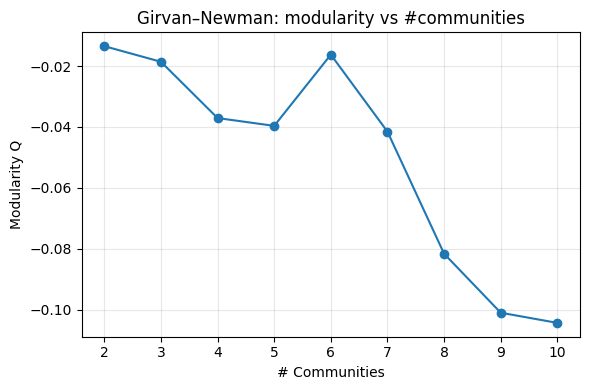

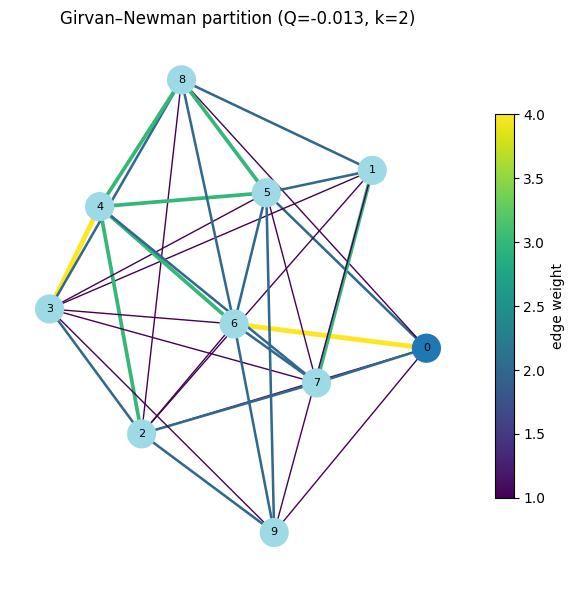

In [6]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import modularity as nx_modularity

def run_gn_select_by_modularity(G, max_levels=20, weight='weight'):
    """Run Girvan–Newman, compute modularity at each split, and pick the best partition.

    Args:
        G: undirected NetworkX graph.
        max_levels: limit number of splits (levels) to examine.
        weight: edge attribute name for weights (used in modularity scoring).
    Returns:
        dict with keys: 'best_partition', 'best_Q', 'history' (list of dicts per level).
    """
    # Ensure undirected for GN (if DiGraph given, convert)
    H = G.to_undirected() if G.is_directed() else G
    comp_gen = girvan_newman(H)
    history = []
    best = None
    for level, communities in enumerate(comp_gen, start=1):
        comms = tuple(sorted((set(c) for c in communities), key=lambda s: min(s)))
        Q = nx_modularity(H, comms, weight=weight)
        record = {'level': level, 'n_comm': len(comms), 'Q': Q, 'communities': comms}
        history.append(record)
        if best is None or Q > best['Q'] or (Q == best['Q'] and len(comms) < best['n_comm']):
            best = record
        if level >= max_levels or len(comms) >= H.number_of_nodes():
            break
    return {'best_partition': best['communities'], 'best_Q': best['Q'], 'history': history}

# Run GN on the same undirected, weighted graph as for Louvain (G)
gn_result = run_gn_select_by_modularity(G, max_levels=30, weight='weight')
gn_best = gn_result['best_partition']
gn_Q = gn_result['best_Q']
gn_hist = gn_result['history']
gn_best_labels = communities_to_labels(gn_best, G.number_of_nodes())
print(f"GN best: Q={gn_Q:.4f}, communities={len(gn_best)}")

# Plot GN modularity vs #communities (if desired)
if plot_perf:
    x = [h['n_comm'] for h in gn_hist]
    y = [h['Q'] for h in gn_hist]
    plt.figure(figsize=(6,4))
    plt.plot(x, y, 'o-')
    plt.xlabel('# Communities')
    plt.ylabel('Modularity Q')
    plt.title('Girvan–Newman: modularity vs #communities')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize GN partition with the same plotting helper
visualize_graph(G, gn_best_labels, title=f"Girvan–Newman partition (Q={gn_Q:.3f}, k={len(gn_best)})")

### 3 - Model Comparison